# 03 — ML Model Selection & Stock Ranking

Auto-selects the most appropriate ML model based on dataset characteristics, trains it, and ranks stocks by predicted return or factor divergence.

**Auto-selection logic:**
| Condition | Model |
|---|---|
| Tiny universe (≤6 stocks) or few features | LASSO — interpretable, sparse |
| Limited history (<150 obs) or many features | PCA + Ridge — prevents overfitting |
| Large history (≥150 obs) and enough data | XGBoost — captures non-linear patterns |

**Inputs:** `data/prices.parquet`, `data/returns.parquet`, `data/factor_scores.parquet`, `data/betas.parquet`  
**Outputs:** `data/ml_rankings.parquet`, `data/feature_importance.parquet`

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# ── XGBoost: install libomp dependency on macOS if needed, then try import ──
import subprocess, platform
XGBOOST_AVAILABLE = False
if platform.system() == 'Darwin':
    result = subprocess.run(['brew', 'install', 'libomp'], capture_output=True, text=True)
    print('libomp:', result.stdout.strip().split('\n')[-1] if result.stdout else 'done')

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print('XGBoost loaded OK.')
except Exception as e:
    print(f'XGBoost unavailable ({e}). Will fall back to PCA+Ridge.')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sys.path.insert(0, '.')
from config import *
print('Ready.')

libomp: done
XGBoost loaded OK.
Ready.


In [2]:
prices       = pd.read_parquet(DATA_DIR + 'prices.parquet')
returns      = pd.read_parquet(DATA_DIR + 'returns.parquet')
factor_z     = pd.read_parquet(DATA_DIR + 'factor_scores.parquet')
beta_df      = pd.read_parquet(DATA_DIR + 'betas.parquet')

ALL_STOCKS = [LONG_CANDIDATE] + SHORT_CANDIDATES
stock_ret  = returns[ALL_STOCKS]
stock_px   = prices[ALL_STOCKS]

print(f'Universe    : {ALL_STOCKS}')
print(f'Returns     : {stock_ret.shape}')
print(f'Factor z    : {factor_z.shape}')
print(f'Betas       : {beta_df.shape}')

Universe    : ['GEVO', 'CHPT', 'BE', 'RUN', 'ARRY', 'HYLN', 'RIVN', 'LCID', 'GOEV', 'ALTO', 'REI', 'PARR', 'AFRM', 'GPRE', 'PLUG', 'AMTX']
Returns     : (1100, 16)
Factor z    : (16, 8)
Betas       : (16, 5)


## 1. Build Feature Matrix

Features per stock per time window:
- Rolling factor scores (time-series, not just snapshot)
- Lagged returns (1m, 3m, 6m, 12m)
- Rolling beta
- Residual momentum (alpha)

In [3]:
def build_panel_features(stock_ret, stock_px, mkt_ret, FORWARD_RETURN_DAYS, resample_freq='M'):
    """
    Build a panel dataset: (date, ticker) -> features + forward return target.
    Returns X (features) and y (forward return) aligned by date.
    """
    frames = []
    for ticker in stock_ret.columns:
        r = stock_ret[ticker].dropna()
        p = stock_px[ticker].dropna()
        
        df = pd.DataFrame(index=r.index)
        df['ret_1m']  = p.pct_change(21)
        df['ret_3m']  = p.pct_change(63)
        df['ret_6m']  = p.pct_change(126)
        df['ret_12m'] = p.pct_change(252)
        df['vol_21d'] = r.rolling(21).std() * np.sqrt(252)
        df['vol_63d'] = r.rolling(63).std() * np.sqrt(252)
        
        # Rolling market beta (60-day)
        cov = r.rolling(60).cov(mkt_ret)
        var = mkt_ret.rolling(60).var()
        df['roll_beta'] = cov / var
        
        # Residual momentum: 21-day alpha
        df['resid_mom'] = r - df['roll_beta'] * mkt_ret
        df['resid_mom_21'] = df['resid_mom'].rolling(21).sum()
        
        # Forward return (target)
        df['fwd_ret'] = r.shift(-FORWARD_RETURN_DAYS).rolling(FORWARD_RETURN_DAYS).sum()
        
        df['ticker'] = ticker
        frames.append(df)
    
    panel = pd.concat(frames)
    panel = panel.dropna()
    return panel

mkt_ret = returns[MARKET_INDEX]
panel   = build_panel_features(stock_ret, stock_px, mkt_ret, FORWARD_RETURN_DAYS)

FEATURE_COLS = ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m',
                'vol_21d', 'vol_63d', 'roll_beta', 'resid_mom_21']

X_panel = panel[FEATURE_COLS]
y_panel = panel['fwd_ret']

print(f'Panel shape   : {panel.shape}')
print(f'Feature cols  : {FEATURE_COLS}')
print(f'Target: forward {FORWARD_RETURN_DAYS}d return')
print(f'Date range    : {panel.index.min().date()} to {panel.index.max().date()}')

Panel shape   : (13248, 11)
Feature cols  : ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'vol_21d', 'vol_63d', 'roll_beta', 'resid_mom_21']
Target: forward 21d return
Date range    : 2022-11-10 to 2026-03-03


## 2. Auto Model Selection

In [4]:
n_stocks   = len(ALL_STOCKS)
n_features = len(FEATURE_COLS)
n_obs      = len(X_panel)

print('=== Auto Model Selection ===')
print(f'  Stocks       : {n_stocks}')
print(f'  Features     : {n_features}')
print(f'  Observations : {n_obs}')
print(f'  XGBoost      : {"available" if XGBOOST_AVAILABLE else "unavailable (libomp missing)"}')

if n_stocks <= 6 or n_features <= 5:
    MODEL_CHOICE = 'LASSO'
    reason = f'Small universe ({n_stocks} stocks) — LASSO enforces sparsity and interpretability.'
elif not XGBOOST_AVAILABLE or n_obs < 150:
    MODEL_CHOICE = 'PCA_RIDGE'
    reason = (f'Limited history ({n_obs} obs) — PCA+Ridge reduces overfitting.' if n_obs < 150
              else 'XGBoost unavailable — falling back to PCA+Ridge.')
else:
    MODEL_CHOICE = 'XGBOOST'
    reason = f'Sufficient data ({n_obs} obs, {n_features} features) — XGBoost captures non-linear interactions.'

print(f'\n>>> Selected: {MODEL_CHOICE}')
print(f'    Reason   : {reason}')

=== Auto Model Selection ===
  Stocks       : 16
  Features     : 8
  Observations : 13248
  XGBoost      : available

>>> Selected: XGBOOST
    Reason   : Sufficient data (13248 obs, 8 features) — XGBoost captures non-linear interactions.


In [5]:
scaler = StandardScaler()
tscv   = TimeSeriesSplit(n_splits=N_CV_FOLDS)

X_scaled = scaler.fit_transform(X_panel)
y_vals   = y_panel.values

# ── LASSO ─────────────────────────────────────────────────────────────────────
def run_lasso(X, y):
    model = LassoCV(cv=TimeSeriesSplit(5), max_iter=5000, random_state=RANDOM_STATE)
    model.fit(X, y)
    coef = pd.Series(model.coef_, index=FEATURE_COLS, name='coef').sort_values(key=abs, ascending=False)
    cv_r2 = cross_val_score(model, X, y, cv=TimeSeriesSplit(5), scoring='r2').mean()
    return model, coef, cv_r2

# ── PCA + Ridge ───────────────────────────────────────────────────────────────
def run_pca_ridge(X, y):
    n_comp = min(n_features, max(2, n_features // 2))
    pipe = Pipeline([
        ('pca',   PCA(n_components=n_comp)),
        ('ridge', RidgeCV(cv=TimeSeriesSplit(5)))
    ])
    pipe.fit(X, y)
    cv_r2 = cross_val_score(pipe, X, y, cv=TimeSeriesSplit(5), scoring='r2').mean()
    # Back-project PCA coef to original feature space
    raw_coef = pipe.named_steps['pca'].components_.T @ pipe.named_steps['ridge'].coef_
    coef = pd.Series(raw_coef, index=FEATURE_COLS, name='coef').sort_values(key=abs, ascending=False)
    return pipe, coef, cv_r2

# ── XGBoost ───────────────────────────────────────────────────────────────────
def run_xgboost(X, y):
    model = xgb.XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective='reg:squarederror', random_state=RANDOM_STATE,
        verbosity=0
    )
    cv_r2 = cross_val_score(model, X, y, cv=TimeSeriesSplit(5), scoring='r2').mean()
    model.fit(X, y)
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS, name='coef').sort_values(ascending=False)
    return model, imp, cv_r2

# ── Run selected model ────────────────────────────────────────────────────────
if MODEL_CHOICE == 'LASSO':
    fitted_model, feature_imp, cv_score = run_lasso(X_scaled, y_vals)
elif MODEL_CHOICE == 'PCA_RIDGE':
    fitted_model, feature_imp, cv_score = run_pca_ridge(X_scaled, y_vals)
else:
    fitted_model, feature_imp, cv_score = run_xgboost(X_scaled, y_vals)

y_pred = fitted_model.predict(X_scaled)
train_r2 = r2_score(y_vals, y_pred)

print(f'Model         : {MODEL_CHOICE}')
print(f'Train R²      : {train_r2:.4f}')
print(f'CV R² (mean)  : {cv_score:.4f}')
print(f'\nFeature importance:')
display(feature_imp.to_frame().round(4))

Model         : XGBOOST
Train R²      : 0.2742
CV R² (mean)  : -0.3627

Feature importance:


,coef
vol_21d,0.1659
ret_12m,0.1510
ret_3m,0.1301
roll_beta,0.1224
vol_63d,0.1216
ret_6m,0.1203
ret_1m,0.1073
resid_mom_21,0.0813


## 3. Stock Ranking & Long/Short Selection

In [6]:
# Predict on LATEST available features for each stock
latest_features = panel.groupby('ticker')[FEATURE_COLS].last()
X_latest = scaler.transform(latest_features[FEATURE_COLS])

pred_returns = pd.Series(
    fitted_model.predict(X_latest),
    index=latest_features.index,
    name='predicted_fwd_ret'
)

# Combine predictions with factor composite score
factor_latest = factor_z['composite'].reindex(pred_returns.index)

ranking = pd.DataFrame({
    'predicted_fwd_ret': pred_returns,
    'factor_composite':  factor_latest,
    'ml_rank':           pred_returns.rank(ascending=False).astype(int),
    'factor_rank':       factor_latest.rank(ascending=False).astype(int),
})
ranking['combined_rank'] = (ranking['ml_rank'] + ranking['factor_rank']) / 2
ranking = ranking.sort_values('combined_rank')
ranking['role'] = ['LONG' if t == LONG_CANDIDATE else 'SHORT' for t in ranking.index]

print('=== Stock Ranking (Lower = Better) ===')
print()
display(ranking.round(4))

ranking.to_parquet(DATA_DIR + 'ml_rankings.parquet')
print('\nSaved ml_rankings.parquet')

=== Stock Ranking (Lower = Better) ===



,predicted_fwd_ret,factor_composite,ml_rank,factor_rank,combined_rank,role
ticker,,,,,,
ALTO,0.1197,0.4846,1,3,2.0,SHORT
PARR,0.0896,0.6229,2,2,2.0,SHORT
RUN,0.0446,-0.0011,3,7,5.0,SHORT
AMTX,0.0356,0.2259,6,5,5.5,SHORT
ARRY,0.0435,-0.0685,4,8,6.0,SHORT
GEVO,-0.0059,0.7640,12,1,6.5,LONG
GPRE,0.0101,0.1546,9,6,7.5,SHORT
REI,-0.0019,0.4174,11,4,7.5,SHORT
RIVN,0.0376,-0.3698,5,12,8.5,SHORT



Saved ml_rankings.parquet


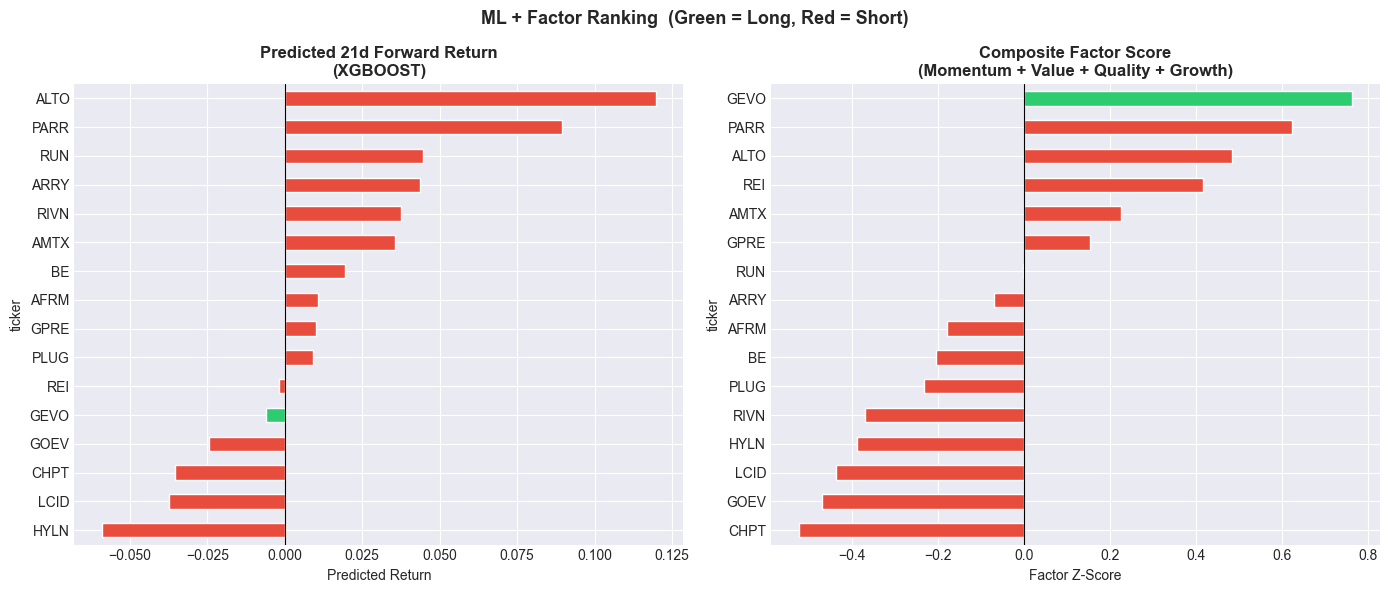


Notebook 03 complete. Run 04_portfolio_construction.ipynb next.


In [7]:
# Ranking visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ecc71' if t == LONG_CANDIDATE else '#e74c3c' for t in ranking.index]

# Predicted return
ranking['predicted_fwd_ret'].sort_values().plot(
    kind='barh', ax=axes[0], color=[colors[ranking.index.get_loc(t)] 
    for t in ranking['predicted_fwd_ret'].sort_values().index],
    edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title(f'Predicted {FORWARD_RETURN_DAYS}d Forward Return\n({MODEL_CHOICE})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Return')

# Composite factor score
ranking['factor_composite'].sort_values().plot(
    kind='barh', ax=axes[1], color=[colors[ranking.index.get_loc(t)]
    for t in ranking['factor_composite'].sort_values().index],
    edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Composite Factor Score\n(Momentum + Value + Quality + Growth)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Factor Z-Score')

plt.suptitle('ML + Factor Ranking  (Green = Long, Red = Short)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '03_ml_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nNotebook 03 complete. Run 04_portfolio_construction.ipynb next.')